In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(505)
n = 300
cols = ['temperature', 'occupancy', 'runtime', 'load']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.4, 0.8, 0.7, 1.1])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["high_demand"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_e.csv", index=False)


In [ ]:
df.describe()

,record_id,temperature,occupancy,runtime,load,high_demand
count,305.000000,290.000000,289.000000,305.000000,305.000000,305.000000
mean,148.081967,50.690828,49.533633,50.506426,49.838820,0.560656
std,88.052447,10.224950,9.812647,10.113146,9.955211,0.497123
min,1.000000,24.870000,18.020000,22.890000,23.290000,0.000000
25%,72.000000,43.217500,43.170000,43.700000,43.160000,0.000000
50%,148.000000,50.525000,49.280000,50.900000,50.050000,1.000000
75%,224.000000,58.190000,56.240000,57.200000,56.890000,1.000000
max,300.000000,84.850000,76.520000,83.480000,80.110000,1.000000


In [ ]:
df.isnull().sum()

,0
record_id,0
temperature,0
occupancy,0
runtime,0
load,0
group,0
high_demand,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   record_id    305 non-null    int64  
 1   temperature  290 non-null    float64
 2   occupancy    289 non-null    float64
 3   runtime      305 non-null    float64
 4   load         305 non-null    float64
 5   group        305 non-null    object 
 6   high_demand  305 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 16.8+ KB


In [ ]:
df['occupancy'].fillna(df['occupancy'].mean(),inplace = True)

/tmp/ipykernel_2158/3548068729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['occupancy'].fillna(df['occupancy'].mean(),inplace = True)


In [ ]:
df['temperature'].fillna(df['temperature'].mean(),inplace = True)

/tmp/ipykernel_2158/4027699520.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['temperature'].fillna(df['temperature'].mean(),inplace = True)


In [37]:
from scipy import stats
df = df.drop_duplicates().reset_index(drop=True)
from sklearn.model_selection import train_test_split
fit_df, test_df = train_test_split( df, test_size=0.20, stratify=df["high_demand"], random_state=42 )
fit_df, val_df = train_test_split( fit_df, test_size=0.20, stratify=fit_df["high_demand"], random_state=42 )

print("fit:", fit_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)

print("fit ids:", len(fit_df["record_id"]))
print("validation ids:", len(val_df["record_id"]))
print("test ids:", len(test_df["record_id"]))
print("all unique:", len(set(fit_df.record_id) | set(val_df.record_id) | set(test_df.record_id)))


fit: (192, 7)
validation: (48, 7)
test: (60, 7)
fit ids: 192
validation ids: 48
test ids: 60
all unique: 300


TASK 1


observed n: 192
mean: 50.28505208333333
median: 49.945
sample std: 10.697027086015463


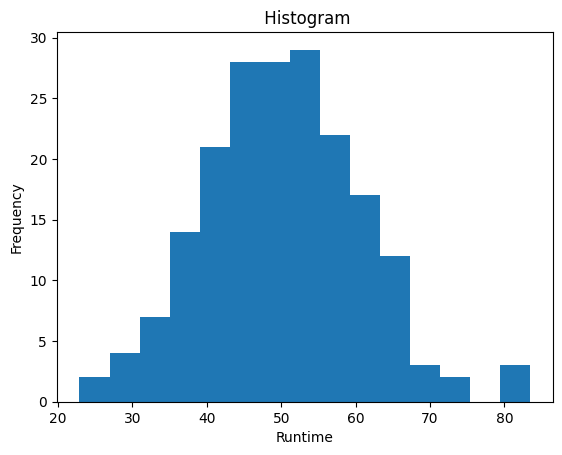

In [41]:
runtime_data = fit_df["runtime"].dropna()
print("observed n:", runtime_data.size)
print("mean:", runtime_data.mean())
print("median:", runtime_data.median())
print("sample std:", runtime_data.std(ddof=1))
plt.hist(runtime_data, bins=15)
plt.title(" Histogram")
plt.xlabel("Runtime")
plt.ylabel("Frequency")
plt.show()

In [44]:

g1 = fit_df.loc[fit_df["group"] == "G1", "runtime"].dropna()
g2 = fit_df.loc[fit_df["group"] == "G2", "runtime"].dropna()
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)
print("G1 count:", len(g1))
print("G2 count:", len(g2))
print("Welch t statistic:", t_stat)
print("p value:", p_value)
runtime_mean_value = runtime_data.mean()
sem = stats.sem(runtime_data)
ci = stats.t.interval(0.95, len(runtime_data)-1, loc=runtime_mean_value, scale=sem)


G1 count: 93
G2 count: 99
Welch t statistic: -1.0807832742604808
p value: 0.28116896543198977


In [46]:
complete = fit_df[["temperature", "load"]].dropna()
X = complete.to_numpy()
X_centered = X - X.mean(axis=0)
covariance = (X_centered.T @ X_centered) / (len(X_centered) - 1)

eigenvalues, eigenvectors = np.linalg.eigh(covariance)
share = eigenvalues[-1] / eigenvalues.sum()

print("complete n:", len(complete))
print("centered matrix:")
print(X_centered)
print("covariance matrix:")
print(covariance)
print("eigenvalues:")
print(eigenvalues)
print("largest variance share:", share)
print("principal direction:")
print(eigenvectors[:, -1])

complete n: 192
centered matrix:
[[ 1.00955733e+01  4.52677083e+00]
 [ 2.45573276e-01 -1.27322917e+00]
 [ 5.35573276e-01 -2.66322917e+00]
 [-6.79442672e+00  3.17677083e+00]
 [-8.12442672e+00 -9.45322917e+00]
 [-1.55442672e+00  3.66770833e-01]
 [-9.10442672e+00  2.18167708e+01]
 [ 9.09557328e+00 -1.48332292e+01]
 [ 6.34557328e+00  1.67708333e-02]
 [-7.98442672e+00 -7.86322917e+00]
 [ 6.23557328e+00 -1.09532292e+01]
 [ 2.65557328e+00 -4.40322917e+00]
 [-2.44267241e-02  4.66677083e+00]
 [-8.31442672e+00 -2.16322917e+00]
 [-1.59244267e+01  4.27677083e+00]
 [ 2.11557328e+00 -1.23732292e+01]
 [ 2.35573276e-01 -9.78322917e+00]
 [ 1.19555733e+01  1.02367708e+01]
 [-1.03599138e-01  7.26677083e+00]
 [-1.29442672e+00  9.50677083e+00]
 [-7.41442672e+00 -8.96322917e+00]
 [ 1.08955733e+01 -1.79322917e+00]
 [-9.08442672e+00 -1.78232292e+01]
 [ 9.86557328e+00 -7.81322917e+00]
 [ 1.86655733e+01  6.60677083e+00]
 [-6.19442672e+00 -4.87322917e+00]
 [ 1.29455733e+01 -5.63229167e-01]
 [ 1.04355733e+01 -9.9

TASK 2

In [49]:
print("--- Initial Data Quality Report ---")
print("Initial DataFrame shape:", df.shape)
initial_duplicates = df.duplicated().sum()
print(f"Number of exact duplicates: {initial_duplicates}")


print("Missing values per column (before cleaning):")
print(df.isnull().sum())
print("\nTarget variable ('high_demand') counts:")
print(df['high_demand'].value_counts())

df_cleaned = df.drop_duplicates().reset_index(drop=True)
unique_records_after_cleaning = df_cleaned['record_id'].nunique()
print(f"\nNumber of unique records after cleaning duplicates: {unique_records_after_cleaning}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

from sklearn.model_selection import train_test_split
fit_df, test_df = train_test_split(df_cleaned, test_size=0.20, stratify=df_cleaned["high_demand"], random_state=42)
fit_df, val_df = train_test_split(fit_df, test_size=0.20, stratify=fit_df["high_demand"], random_state=42)
print("\n--- Data Partitions ---")
print("Fit DataFrame shape:", fit_df.shape)
print("Validation DataFrame shape:", val_df.shape)
print("Test DataFrame shape:", test_df.shape)


fit_ids = set(fit_df['record_id'])
val_ids = set(val_df['record_id'])
test_ids = set(test_df['record_id'])

print(f"\nFit IDs count: {len(fit_ids)}")
print(f"Validation IDs count: {len(val_ids)}")
print(f"Test IDs count: {len(test_ids)}")



--- Initial Data Quality Report ---
Initial DataFrame shape: (300, 7)
Number of exact duplicates: 0
Missing values per column (before cleaning):
record_id      0
temperature    0
occupancy      0
runtime        0
load           0
group          0
high_demand    0
dtype: int64

Target variable ('high_demand') counts:
high_demand
1    170
0    130
Name: count, dtype: int64

Number of unique records after cleaning duplicates: 300
Cleaned DataFrame shape: (300, 7)

--- Data Partitions ---
Fit DataFrame shape: (192, 7)
Validation DataFrame shape: (48, 7)
Test DataFrame shape: (60, 7)

Fit IDs count: 192
Validation IDs count: 48
Test IDs count: 60


In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
id_col = 'record_id'
target_col = 'high_demand'
impute_numeric_cols = ['temperature', 'occupancy']
scale_only_numeric_cols = ['runtime', 'load']
categorical_cols = ['group']

#  Imputation and One-Hot Encoding ---
print("--- Stage 1: Imputation and One-Hot Encoding ---")
# Median Imputation
median_imputer = SimpleImputer(strategy='median')
median_imputer.fit(fit_df[impute_numeric_cols])


fit_df[impute_numeric_cols] = median_imputer.transform(fit_df[impute_numeric_cols])
val_df[impute_numeric_cols] = median_imputer.transform(val_df[impute_numeric_cols])
test_df[impute_numeric_cols] = median_imputer.transform(test_df[impute_numeric_cols])

print("Median imputation applied to 'temperature' and 'occupancy' in fit, val, test sets.")
print(f"Missing values in fit_df after imputation: {fit_df[impute_numeric_cols].isnull().sum().sum()}")
print(f"Missing values in val_df after imputation: {val_df[impute_numeric_cols].isnull().sum().sum()}")
print(f"Missing values in test_df after imputation: {test_df[impute_numeric_cols].isnull().sum().sum()}")



ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_encoder.fit(fit_df[categorical_cols])

fit_encoded_cols = ohe_encoder.transform(fit_df[categorical_cols])
val_encoded_cols = ohe_encoder.transform(val_df[categorical_cols])
test_encoded_cols = ohe_encoder.transform(test_df[categorical_cols])

--- Stage 1: Imputation and One-Hot Encoding ---
Median imputation applied to 'temperature' and 'occupancy' in fit, val, test sets.
Missing values in fit_df after imputation: 0
Missing values in val_df after imputation: 0
Missing values in test_df after imputation: 0


KeyError: "None of [Index(['group'], dtype='object')] are in the [columns]"

TASK 3


In [52]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_true = np.array([0, 1, 0, 1, 0, 1, 1, 0, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0, 1, 1, 1, 0])
print("True Labels (y_true): ", y_true)
print("Predicted Labels (y_pred):", y_pred)
cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix:\n", cm)
print(f"\nTrue Positives (TP): {tp} (Correctly predicted positive)")
print(f"False Positives (FP): {fp} (Incorrectly predicted positive)")
print(f"False Negatives (FN): {fn} (Incorrectly predicted negative)")
print(f"True Negatives (TN): {tn} (Correctly predicted negative)")

True Labels (y_true):  [0 1 0 1 0 1 1 0 1 0]
Predicted Labels (y_pred): [0 1 1 1 0 0 1 1 1 0]

Confusion Matrix:
 [[3 2]
 [1 4]]

True Positives (TP): 4 (Correctly predicted positive)
False Positives (FP): 2 (Incorrectly predicted positive)
False Negatives (FN): 1 (Incorrectly predicted negative)
True Negatives (TN): 3 (Correctly predicted negative)
